In [1]:
#Z = 2X**2 - 3Y**2 + 1 + ϵ 

In [2]:
import sys
sys.path.append("../")

In [35]:
import numpy as np
import keras
import matplotlib.pyplot as plt
#%matplotlib inline
#from reco import vis

In [10]:
x=np.arange(-1,1,0.01)
y=np.arange(-1,1,0.01)

X,Y=np.meshgrid(x,y)
c=np.ones((200,200))
e=np.random.rand(200,200)*0.1

In [12]:
Z = 2*X*X - 3*Y*Y + 5*c + e

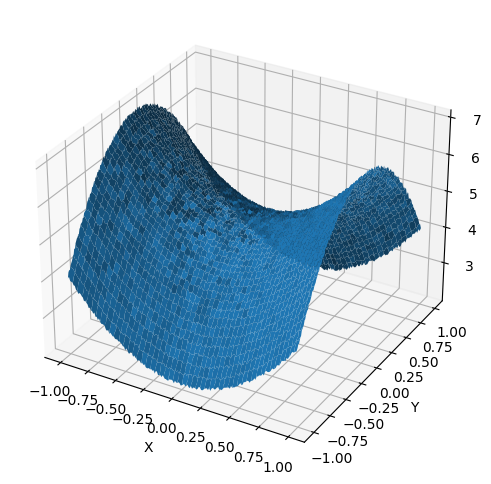

In [36]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()
#vis.plot3d(X,Y,Z)

In [37]:
from keras.models import Sequential
from keras.layers import Dense

In [38]:
input_xy = np.c_[X.reshape(-1), Y.reshape(-1)]
output_z = Z.reshape(-1)

In [39]:
input_xy.shape, output_z.shape

((40000, 2), (40000,))

In [82]:
model = Sequential()
model.add(Dense(64, input_dim=2, activation="relu"))
model.add(Dense(32, input_dim=2, activation="relu"))
model.add(Dense(16, input_dim=2, activation="relu"))
model.add(Dense(1))

In [83]:
model.summary

<bound method Model.summary of <Sequential name=sequential_5, built=True>>

In [84]:
model.compile(loss="mean_squared_error", optimizer="sgd", metrics=["mse"])

In [85]:
output = model.fit(input_xy, output_z, epochs=20, validation_split=0.2, shuffle=True, verbose=1)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3380 - mse: 0.3380 - val_loss: 0.9418 - val_mse: 0.9418
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.7089 - val_mse: 0.7089
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - loss: 0.0029 - mse: 0.0029 - val_loss: 0.6237 - val_mse: 0.6237
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0020 - mse: 0.0020 - val_loss: 0.5636 - val_mse: 0.5636
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0017 - mse: 0.0017 - val_loss: 0.5263 - val_mse: 0.5263
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0015 - mse: 0.0015 - val_loss: 0.4960 - val_mse: 0.4960
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 0.4848 - val_mse: 0.4848
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 0.4645 - val_mse: 0.4645
Epoch 9/20
1000/1000 ━━━━━━━━━━━━━━━

In [86]:
print(output.history.keys())

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])


In [87]:
history = output.history

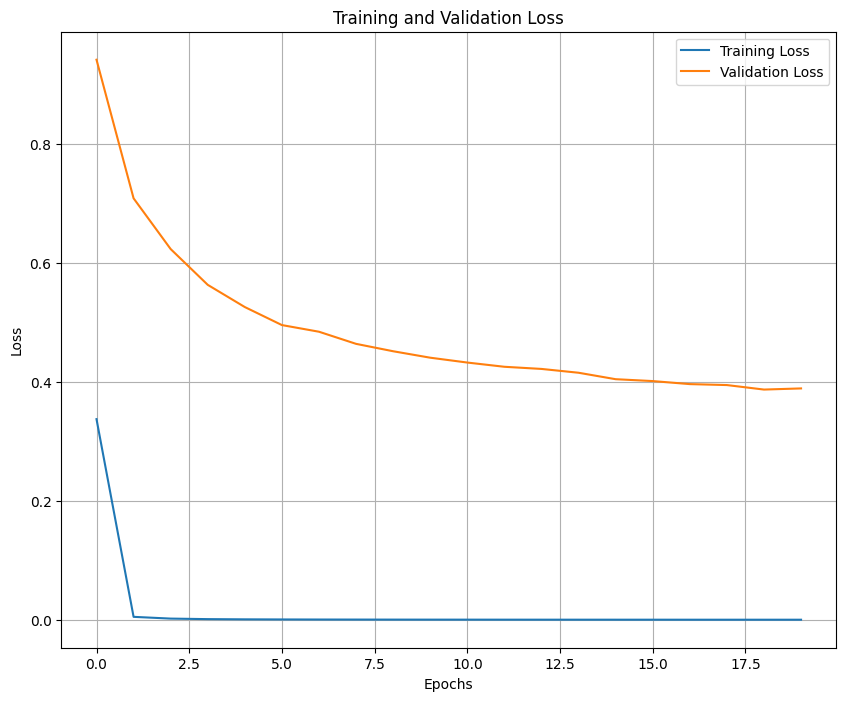

In [88]:
plt.figure(figsize=(10,8))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [89]:
z_pred = model.predict(input_xy).reshape(200,200)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


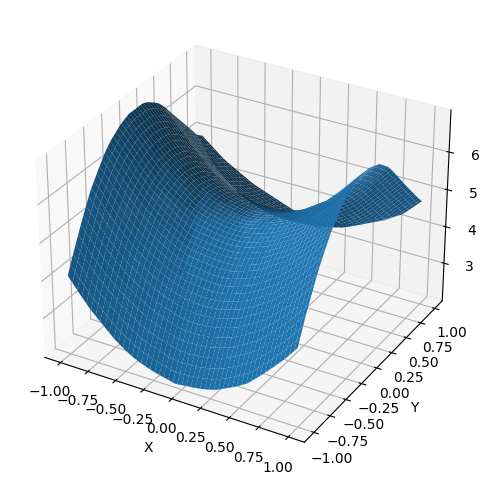

In [90]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, z_pred)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z_pred")

plt.show()